# Evaluation of Full LLM Agent Graph routing decision making

In [1]:
import os
import sys
import pickle
from pathlib import Path

import dotenv
dotenv.load_dotenv(Path.cwd().parent / '.env')

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent))
from src.router import NaiveRouter, StaticRouter

from solutions.evaluation.benchmarking import SAMPLE_QUERIES, ALL_QUERIES, benchmark_router, benchmark_all_routers\

from solutions.custom_router import CustomRouter
seed = 42

evaluate_model = "gemma-3-27b"

In [2]:
import logging
logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s %(name)s %(levelname)s %(message)s",
)

## Benchmarking

### Baselines

In [ ]:
naive_router = NaiveRouter(edge_probability=0.5)
naive_router_result = await benchmark_router(router=naive_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1, 
                                             evaluator_model=evaluate_model)
with open("naive_router_result.pkl", "wb") as f:
        pickle.dump({naive_router.name: naive_router_result}, f)

In [ ]:
static_small_router = StaticRouter("gemma-3-4b")
static_small_result = await benchmark_router(router=static_small_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1, 
                                             evaluator_model=evaluate_model)
with open("static_small_result.pkl", "wb") as f:
        pickle.dump({static_small_router.name: static_small_result}, f)

In [ ]:
static_smallx_router = StaticRouter("gemma-3n-e4b")
static_smallx_result = await benchmark_router(router=static_smallx_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1, 
                                             evaluator_model=evaluate_model)
with open("static_smallx_result.pkl", "wb") as f:
        pickle.dump({static_smallx_router.name: static_smallx_result}, f)

In [ ]:
static_median_router = StaticRouter("gemma-3-12b")
static_median_result = await benchmark_router(router=static_median_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1,
                                              evaluator_model=evaluate_model)
with open("static_median_result.pkl", "wb") as f:
        pickle.dump({static_median_router.name: static_median_result}, f)

In [ ]:
static_large_router = StaticRouter("gemma-3-27b")
static_large_result = await benchmark_router(router=static_large_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1, 
                                             evaluator_model=evaluate_model)
with open("static_large_result.pkl", "wb") as f:
        pickle.dump({static_large_router.name: static_large_result}, f)

In [ ]:
static_xlarge_router = StaticRouter("nemotron-nano")
static_xlarge_result = await benchmark_router(router=static_xlarge_router, queries=ALL_QUERIES, seed=seed, max_concurrent=1,
                                              evaluator_model=evaluate_model)
with open("static_xlarge_result.pkl", "wb") as f:
        pickle.dump({static_xlarge_router.name: static_xlarge_result}, f)

#### Error on 'split'
Due to the max_token setting in benchmark

### Custom Routers

In [3]:
v5_model_assignment = {
    # "decision": "gemma-3-12b",
    "decision": "gemma-3n-e4b",
}

#### Meta routers

In [ ]:
meta_router_v5 = CustomRouter(use_meta_routing=True, prompt_version="v5", max_tokens=1000, name="MetaRouterV5", 
                              model_assignments=v5_model_assignment)
meta_router_v5_result = await benchmark_router(router=meta_router_v5, queries=ALL_QUERIES, seed=seed,
                                               max_concurrent=1, evaluator_model=evaluate_model)
with open("meta_router_v5_result.pkl", "wb") as f:
        pickle.dump({meta_router_v5.name: meta_router_v5_result}, f)

meta_router_v5.save("meta_router_v5_monitor.pkl")

#### Graph routers

In [ ]:
graph_router_v5 = CustomRouter(use_meta_routing=False, prompt_version="v5", max_tokens=1000, name="GraphRouterV5", 
                               confidence_threshold=1.0, model_assignments=v5_model_assignment)
graph_router_v5_result = await benchmark_router(router=graph_router_v5, queries=ALL_QUERIES, seed=seed,
                                                max_concurrent=1, evaluator_model=evaluate_model)
with open("graph_router_v5_result.pkl", "wb") as f:
        pickle.dump({graph_router_v5.name: graph_router_v5_result}, f)

graph_router_v5.save("graph_router_v5_monitor.pkl")

#### Fast Graph routers

In [ ]:
fast_graph_router_v5 = CustomRouter(use_meta_routing=False, prompt_version="v5", max_tokens=1000, name="FastGraphRouterV5",
                                    model_assignments=v5_model_assignment)
fast_graph_router_v5_result = await benchmark_router(router=fast_graph_router_v5, queries=ALL_QUERIES, seed=seed,
                                                     max_concurrent=1, evaluator_model=evaluate_model)
with open("fast_graph_router_v5_result.pkl", "wb") as f:
        pickle.dump({fast_graph_router_v5.name: fast_graph_router_v5_result}, f)

fast_graph_router_v5.save("fast_graph_router_v5_monitor.pkl")

## Evaluation

In [1]:
from solutions.evaluation.benchmarking import print_benchmark_summary, print_router_comparison, ALL_QUERIES
from solutions.evaluation.data_loading import load_all_results
from solutions.evaluation.frame import evaluation_frame_from_dir
from solutions.evaluation.quality_comparison import plot_overall_quality, plot_per_category_quality, build_quality_summary_table
from solutions.evaluation.routing_decisions import build_routing_decisions_table, build_pipeline_trace_table, save_routing_decisions_image
from solutions.evaluation.routing_decisions import style_routing_decisions_table
from solutions.evaluation.latency_analysis import *
from solutions.evaluation.cost_analysis import *
from solutions.evaluation import evaluation_frame_from_dir, render_traces

In [2]:
total_queries = sum([len(ALL_QUERIES[i]) for i in ALL_QUERIES])

router_order = [
    "Random", "Static(gemma-3-4b@edge)", "Static(gemma-3n-e4b@edge)", 
    "Static(gemma-3-12b@cloud)", "Static(gemma-3-27b@cloud)", "Static(nemotron-nano@cloud)",
    "FastGraphRouterV5", "GraphRouterV5", "MetaRouterV5"
]

router_results = load_all_results("./token_1000/", filter_routers=router_order)
evaluation_df, step_df = evaluation_frame_from_dir("./token_1000/", include_reasoning=True, filter_routers=router_order)

# router_order = [
#     "Random", "Static(gemma-3-4b@edge)", "Static(gemma-3n-e4b@edge)", 
#     "Static(gemma-3-12b@cloud)", "Static(gemma-3-27b@cloud)", "Static(nemotron-nano@cloud)",
#     "FastGraphRouterV1", "FastGraphRouterV2", "FastGraphRouterV3", "FastGraphRouterV4", 
#     "GraphRouterV1", "GraphRouterV2", "GraphRouterV3", "GraphRouterV4", 
#     "MetaRouterV1", "MetaRouterV2", "MetaRouterV3", "MetaRouterV4",
# ]

### Details of methods

We design a custom router to select the most appropriate LLM for answering a user query. The overall workflow is shown below.

![Workflow Graph](./source/flow_chart.png)

We conduct experiments on 11 different routers, including 5 baseline routers: a random router and 4 static routers using one small, one medium, and two large models. The router settings are as follows:

* **Random**: Randomly selects an LLM for each query, with a 50\% probability of deploying the selected LLM on the edge.
* **Static (gemma-3-4b)**: Uses gemma-3-4b for all queries (small LLM).
* **Static (gemma-3n-e4b@edge)**: Uses gemma-3n-e4b@edge for all queries (small LLM).
* **Static (gemma-3-12b)**: Uses gemma-3-12b for all queries (medium LLM).
* **Static (gemma-3-27b)**: Uses gemma-3-27b for all queries (large LLM).
* **Static (nemotron-nano)**: Uses nemotron-nano for all queries (30B large LLM).
* **FastGraphRouter**: Includes a skip path when the intent node classifies the query as a simple factual query. In this case, it directly selects a small LLM deployed on the edge.
* **GraphRouter**: Executes the complete workflow pipeline.
* **MetaRouter**: Uses a meta-router to select the LLM for each node in the workflow. 


### Comparison between methods

In [3]:
print_router_comparison(router_results)


ROUTER COMPARISON

Router                               Queries  Avg Latency  Avg Quality     Total Cost
----------------------------------------------------------------------------------------------------
FastGraphRouterV5                         15       9235ms        8.97/10 $    0.000409
GraphRouterV5                             15       9341ms        8.87/10 $    0.000407
MetaRouterV5                              15      12884ms        8.87/10 $    0.000215
Random                                    11      11266ms        8.82/10 $    0.000152
Static(gemma-3-27b@cloud)                 15      18968ms        8.60/10 $    0.000085
Static(gemma-3-12b@cloud)                 15      20920ms        8.70/10 $    0.000034
Static(gemma-3-4b@edge)                   15       3766ms        8.70/10 $    0.000017
Static(gemma-3n-e4b@edge)                 15       3701ms        8.80/10 $    0.000687
Static(nemotron-nano@cloud)               15       4515ms        8.67/10 $    0.008187
----------

### Quality comparison

#### Overall Mean Quality

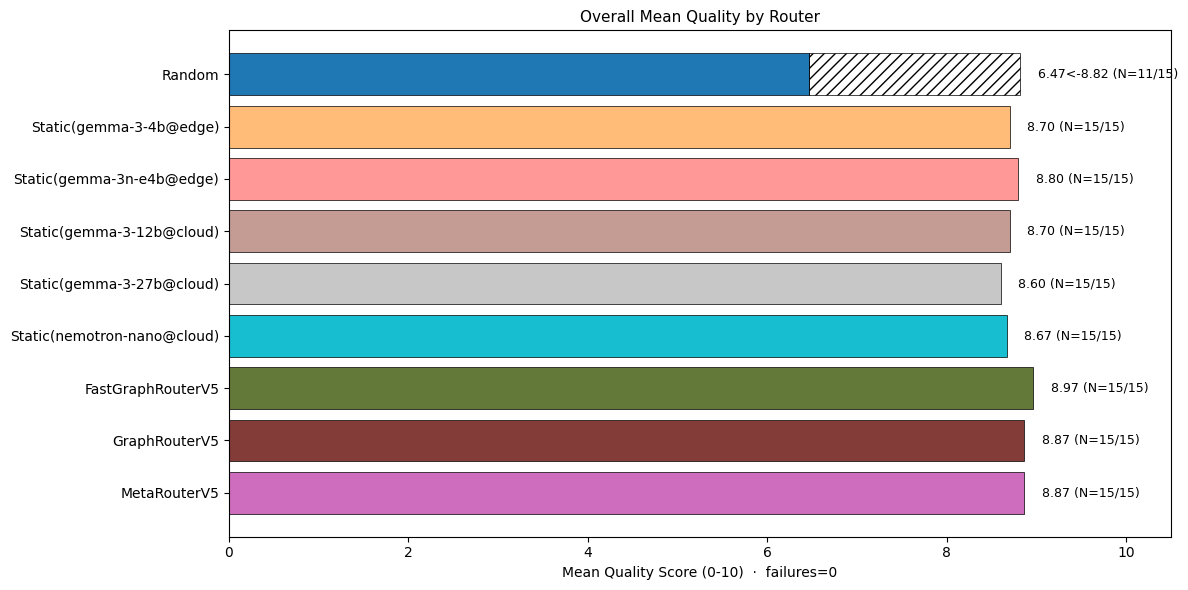

In [4]:
fig, _ = plot_overall_quality(
    evaluation_df, 
    router_order=router_order,
    figsize=(12, 6), 
    fontsize=9, 
    penalize_failures=True, 
    total_queries=total_queries, 
    show_errorbar=False
)
fig.savefig("./source/qualtiy_comparison.png")

Routers may select LLMs that are not available on OpenRouter, which can lead to an unfair comparison when calculating mean quality. To address this, we penalize unfinished queries by assigning a quality score of 0.

The figure above shows the penalized quality scores across different routing strategies. FastGraphRouter with the V5 achieves the highest overall mean quality score, with a score of 8.97. The results also suggest that other custom routing strategies with V5 prompt outperform the static baselines, indicating that adaptive routing can improve response quality. However, the performance gaps are relatively small, so additional data would be needed to determine whether these differences are statistically significant.

#### Quality score over different query types

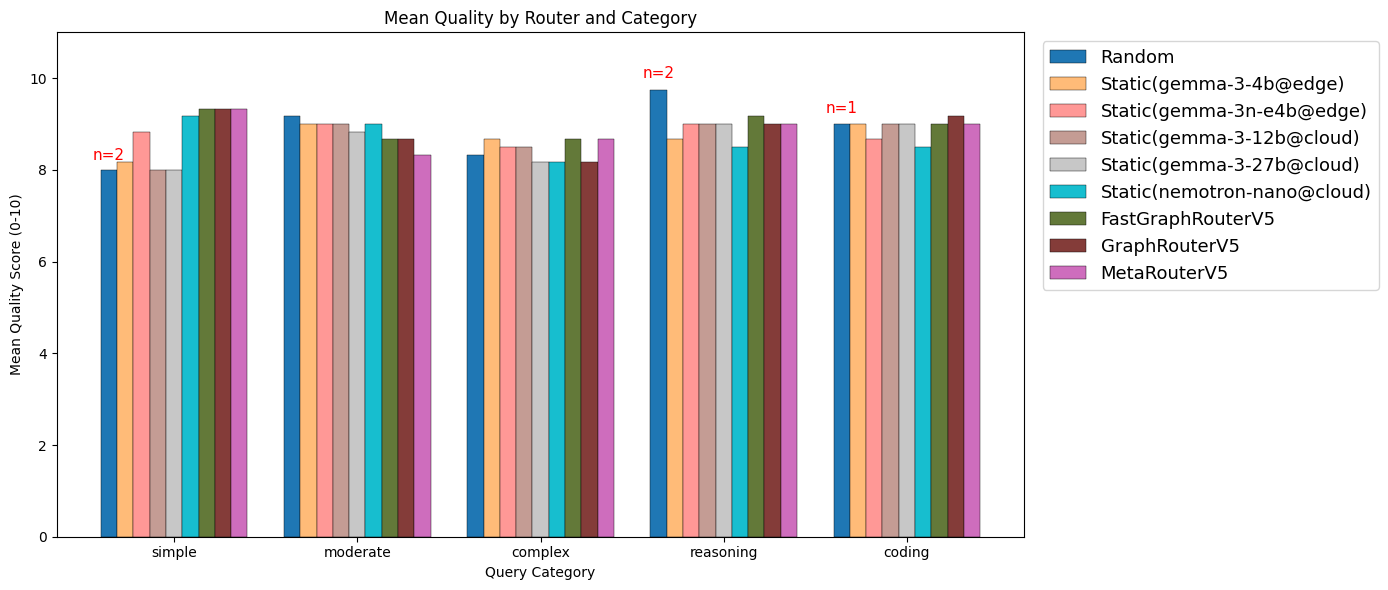

In [5]:
fig, _ = plot_per_category_quality(
    evaluation_df, 
    router_order=router_order,
    figsize=(14, 6), 
    fontsize=11, 
    penalize_failures=False, 
    total_queries=total_queries, 
    show_errorbar=False
)
fig.savefig("./source/group_qualtiy_comparison.png")

This figure presents the quality scores grouped by query type.

For simple queries, the custom routers achieve higher quality scores than the static baselines. However, for moderate queries, the static baselines perform slightly better than custom routers.

The routers achieve very similar quality scores on coding queries. One possible explanation is that using an LLM-as-a-Judge to evaluate coding responses may be less reliable, because the judge may not be able to fully verify whether the generated code correctly solves the task. A sandbox-based execution environment would provide a more robust evaluation method for coding queries, as it could directly test code correctness against predefined test cases.

An interesting result shows in the complex query category. Static routers with small LLM achieve relatively high quality scores compared with routers that use larger models. This result is unexpected, as larger models are generally assumed to have stronger reasoning and answer-generation capabilities, especially for more difficult queries. However, this observation should be interpreted carefully, since it may be affected by the small number of examples or by variation in the scoring.

Overall, while the results suggest that custom routers can improve quality on certain query types, the differences between routers are generally small. Since each query category contains only three queries, the sample size is too limited to support strong conclusions. Additional data would be needed to determine whether the observed differences are meaningful and consistent.

### Routing Decision Analysis

In [6]:
routing_table = build_routing_decisions_table(evaluation_df, router_order=router_order)
routers = [
    "FastGraphRouterV5", "GraphRouterV5", "MetaRouterV5",
]

In [8]:
save_routing_decisions_image(routing_table, path="source/routing_decision_simple.png", categories=["simple"], routers=routers,
                            figsize=(20, 4))
style_routing_decisions_table(routing_table, categories=["simple"], routers=routers)

category,router,model_selections,edge_deployment,cloud_deployment,tier_mode,tier_agreement,mean_quality,mean_latency_ms,mean_cost,mean_mission_score,mean_latency_score
simple,FastGraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.33,362,$0.000004,—,—
simple,GraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.33,518,$0.000003,0.25,0.72
simple,MetaRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.33,251,$0.000002,—,—


For simple queries, all custom routers select small edge-deployed models. This indicates that the routers can successfully identify simple factual queries and route them to lightweight models for efficient execution. The simple queries receive higher latency-criticality scores than mission-criticality scores in the GraphRouter. The mission-criticality score is 0.25, while the latency-criticality score is 0.72. This suggests that the router consider simple queries as less mission-critical but more latency-sensitive. The make the routers prefer the selection of smaller edge-deployed models. Overall, the results show that the routing logic behaves as expected for simple factual queries by prioritizing efficiency without relying on larger cloud-based models.

In [9]:
save_routing_decisions_image(routing_table, path="source/routing_decision_moderate.png", categories=["moderate"], routers=routers,
                            figsize=(20, 4))
style_routing_decisions_table(routing_table, categories=["moderate"], routers=routers)

category,router,model_selections,edge_deployment,cloud_deployment,tier_mode,tier_agreement,mean_quality,mean_latency_ms,mean_cost,mean_mission_score,mean_latency_score
moderate,FastGraphRouterV5,"gemma-3n-e4b (2), gemma-3-4b (1)",3,0,small,100%,8.67,6622,$0.000051,0.50,0.52
moderate,GraphRouterV5,"gemma-3n-e4b (2), gemma-3-4b (1)",3,0,small,100%,8.67,6514,$0.000051,0.50,0.52
moderate,MetaRouterV5,"gemma-3-4b (2), gemma-3n-e4b (1)",3,0,small,100%,8.33,6790,$0.000027,0.50,0.60


For moderate queries, the intent node classifies the query as a non-simple-factual, and therefore the fast decision path in FastGraphRouter is not activated. This suggests that the intent node is functioning as intended.

The mission-criticality score for the moderate queries is 0.5 and the latency-criticality score range from 0.52 to 0.60. For moderate queries, the latency-criticality score is slightly larger than the mission-criticality score and therefore, the decision node tend to select small LLM on the edge.

In [10]:
save_routing_decisions_image(routing_table, path="source/routing_decision_complex.png", categories=["complex"], routers=routers,
                            figsize=(20, 4))
style_routing_decisions_table(routing_table, categories=["complex"], routers=routers)

category,router,model_selections,edge_deployment,cloud_deployment,tier_mode,tier_agreement,mean_quality,mean_latency_ms,mean_cost,mean_mission_score,mean_latency_score
complex,FastGraphRouterV5,gemma-3-27b (3),0,3,medium,100%,8.67,32781,$0.000006,0.70,0.55
complex,GraphRouterV5,gemma-3-27b (3),0,3,medium,100%,8.17,33121,$0.000006,0.70,0.55
complex,MetaRouterV5,"gemma-3-27b (2), gemma-3n-e4b (1)",1,2,medium,67%,8.67,24862,$0.000031,0.67,0.63


For most complex queries, the custom routers select a medium-tier LLM. Since larger and reasoning-specialized LLMs are currently unavailable on OpenRouter, these medium-tier models represent the most capable available options for complex queries. The mission-criticality scores for complex queries are higher than those for moderate queries，ranging from  0.67 to 0.70. The latency scores range from approximately 0.55 to 0.63. This suggests that complex queries are treated as relatively mission-critical, so the routers usually prioritize model capability and select medium-tier cloud models.

In [11]:
save_routing_decisions_image(routing_table, path="source/routing_decision_coding.png", categories=["coding"], routers=routers,
                            figsize=(20, 4))
style_routing_decisions_table(routing_table, categories=["coding"], routers=routers)

category,router,model_selections,edge_deployment,cloud_deployment,tier_mode,tier_agreement,mean_quality,mean_latency_ms,mean_cost,mean_mission_score,mean_latency_score
coding,FastGraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.00,5450,$0.000063,0.65,0.65
coding,GraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.17,5702,$0.000064,0.65,0.65
coding,MetaRouterV5,"gemma-3-12b (2), gemma-3-27b (1)",0,3,medium,100%,9.00,31576,$0.000002,0.60,0.63


For coding queries, the routers generally tend to select small edge-deployed LLMs, except for MetaRouterV5, which select medium cloud-based models. For FastGraphRouter and GraphRouter, the mission-criticality score and the latency-criticality score are tight (both are 0.65). In this situation, the prompt tend to select a medium-tier LLM, but `gemma-3n-e4B` tend to select a small LLM on the edge. While for MetaRouter, the decision node is run with `gemma-3-4B` make the coherent decision by selecting the medium tier model on the cloud when the mission-criticality and latency-criticality are high and tight.

In [12]:
save_routing_decisions_image(routing_table, path="source/routing_decision_reasoning.png", categories=["reasoning"], routers=routers,
                            figsize=(20, 4))
style_routing_decisions_table(routing_table, categories=["reasoning"], routers=routers)

category,router,model_selections,edge_deployment,cloud_deployment,tier_mode,tier_agreement,mean_quality,mean_latency_ms,mean_cost,mean_mission_score,mean_latency_score
reasoning,FastGraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.17,959,$0.000013,0.40,0.65
reasoning,GraphRouterV5,gemma-3n-e4b (3),3,0,small,100%,9.00,849,$0.000011,0.40,0.65
reasoning,MetaRouterV5,"gemma-3n-e4b (2), gemma-3-4b (1)",3,0,small,100%,9.00,943,$0.000009,0.60,0.63


For reasoning queries, most routers tend to select small edge-deployed models. The mission-criticality scores are generally low to moderate, ranging from approximately 0.4 to 0.60. The latency scores range from approximately 0.63 to 0.65. This shows that the routing decision is strongly influenced by the mission-criticality and latency scoring nodes. Since reasoning queries are not classified as highly mission-critical, the routers tend to select efficient edge deployment. In addition, reasoning models are not included in the final selection because they are currently unavailable on OpenRouter. This limits the router to choose reasoning models for these reasoning tasks.

### Latency Analysis

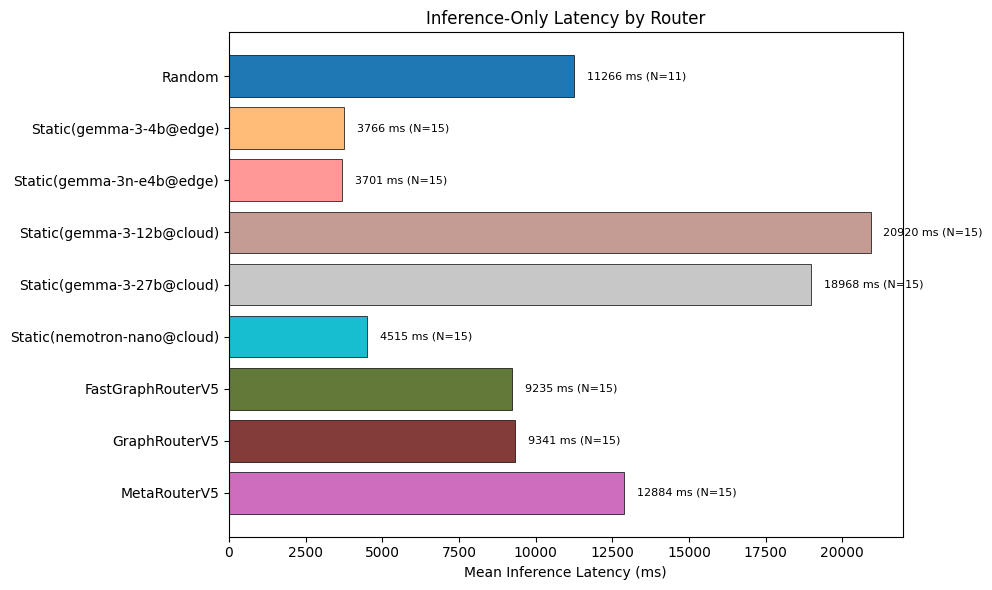

In [15]:
fig, _ = plot_inference_overall(evaluation_df, router_order=router_order, figsize=(10, 6), show_errorbar=False)
fig.savefig("./source/inference_latency.png")

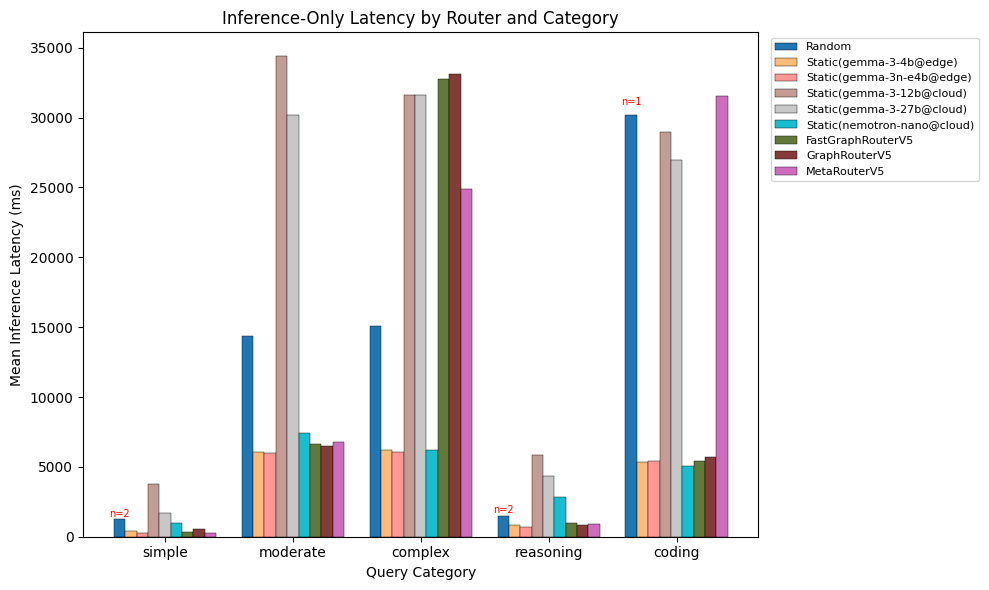

In [16]:
fig, _ = plot_inference_per_category(evaluation_df, router_order=router_order, show_errorbar=False)
fig.savefig(
    "./source/group_inference_lantecy.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

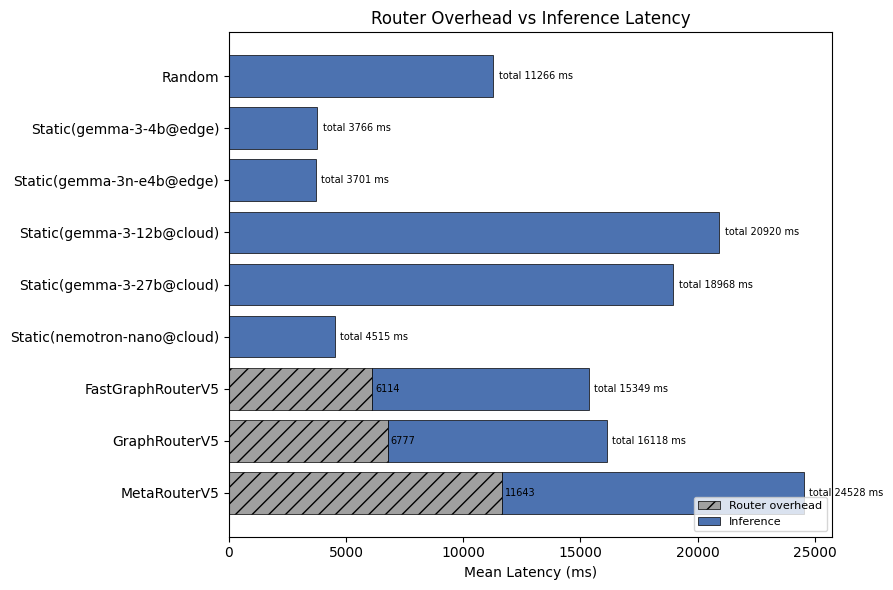

In [17]:
fig, _ = plot_split_overall(evaluation_df, router_order=router_order)
fig.savefig("./source/overall_latency.png")

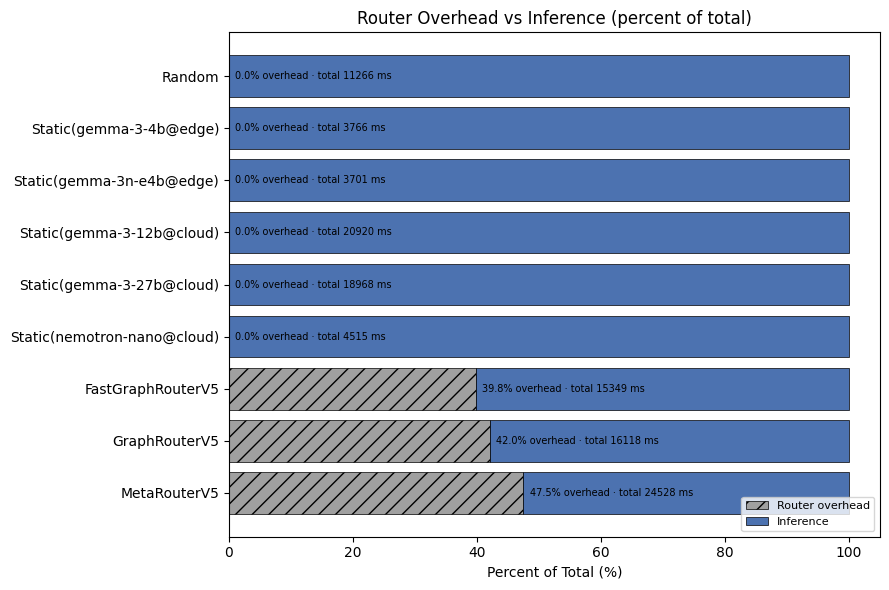

In [18]:
fig, _ = plot_split_overall_pct(evaluation_df, router_order=router_order)
fig.savefig("./source/overall_latency_percentage.png")

The custom routers introduce substantial latency overhead because they require additional LLM calls during the routing pipeline, such as intent classification, mission-criticality scoring, latency-criticality scoring, and final deployment decision-making. In contrast, the static baselines incur no routing overhead because they send each query directly to a fixed model.

Overall, the static edge baselines have the lowest total latency when the router selects a small LLM deployed on the edge, whereas static cloud models have much higher inference latency. Among the custom routers, FastGraphRouterV5 achieves the lowest total latency because it make direct decision when the intent node classify the query type as simple factual. This reduce the overhead of the scoring and decision node.

Routing overhead accounts for a moderate portion of the total latency in adaptive routers. For GraphRouter and MetaRouter, the overhead contributes 42\% and 47.5\% of total latency, respectively. MetaRouter has higher overhead because it includes an additional meta-routing step and may use larger LLMs in later routing nodes.

FastGraphRouter reduces this cost through its skip path, which allows simple factual queries to bypass part of the routing pipeline and directly select a small edge-deployed model. The routing overhead contribute about 39.8\% of overhead in the total latency. A similar mechanism in MetaRouter also helps limit the routing-overhead ratio compared with the full routing process.

Overall, the results show that adaptive routing strategies provide greater decision flexibility, but this benefit comes at the cost of increased routing latency.

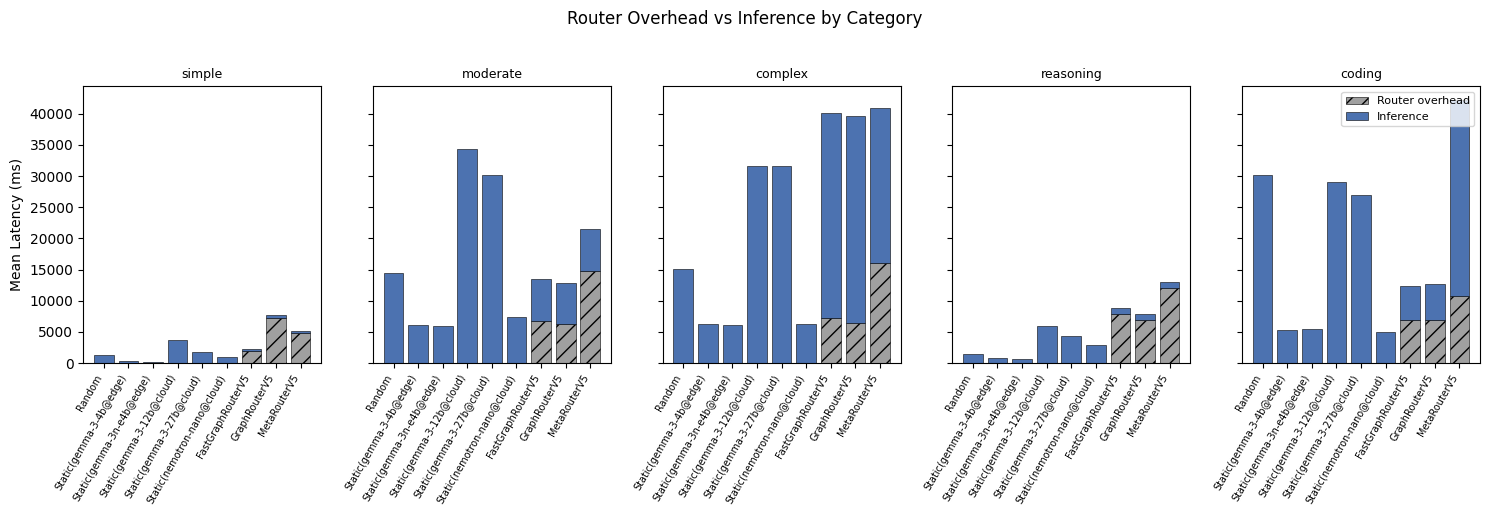

In [19]:
fig, _ = plot_split_per_category(evaluation_df, router_order=router_order)
fig.savefig(
    "./source/group_lantecy.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

When we analyze routing overhead by query type, we observe that for simple and reasoning queries, routing overhead accounts for a larger share of total latency than it does for moderate and complex queries. This is because, for simple and reasoning queries, the answering LLM generates fewer tokens, which leads to lower inference latency, while the routing overhead does not decrease significantly.

By contrast, for moderate, complex, and coding queries, the proportion of total latency attributable to routing overhead decreases.

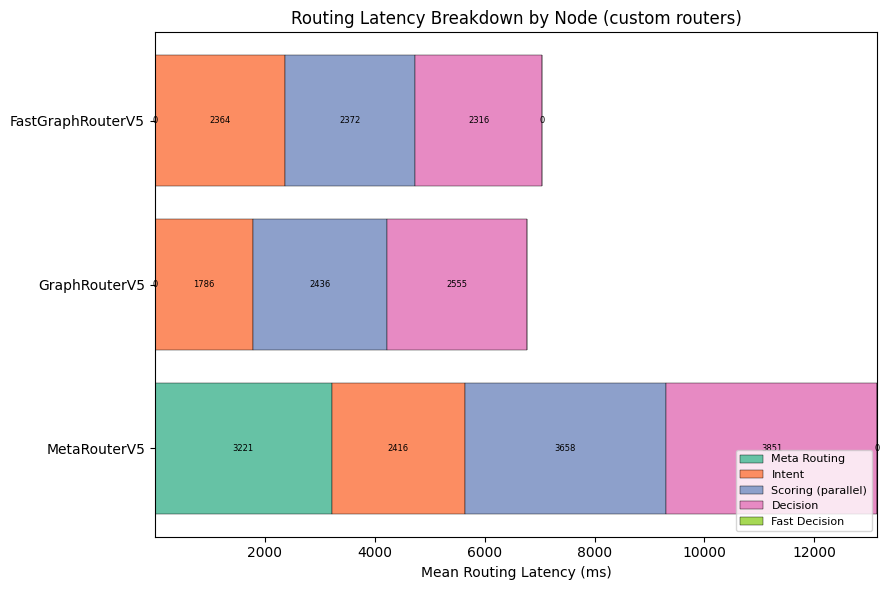

In [20]:
fig, _ = plot_node_breakdown_overall(step_df, router_order=router_order)
fig.savefig("./source/step_latency.png")

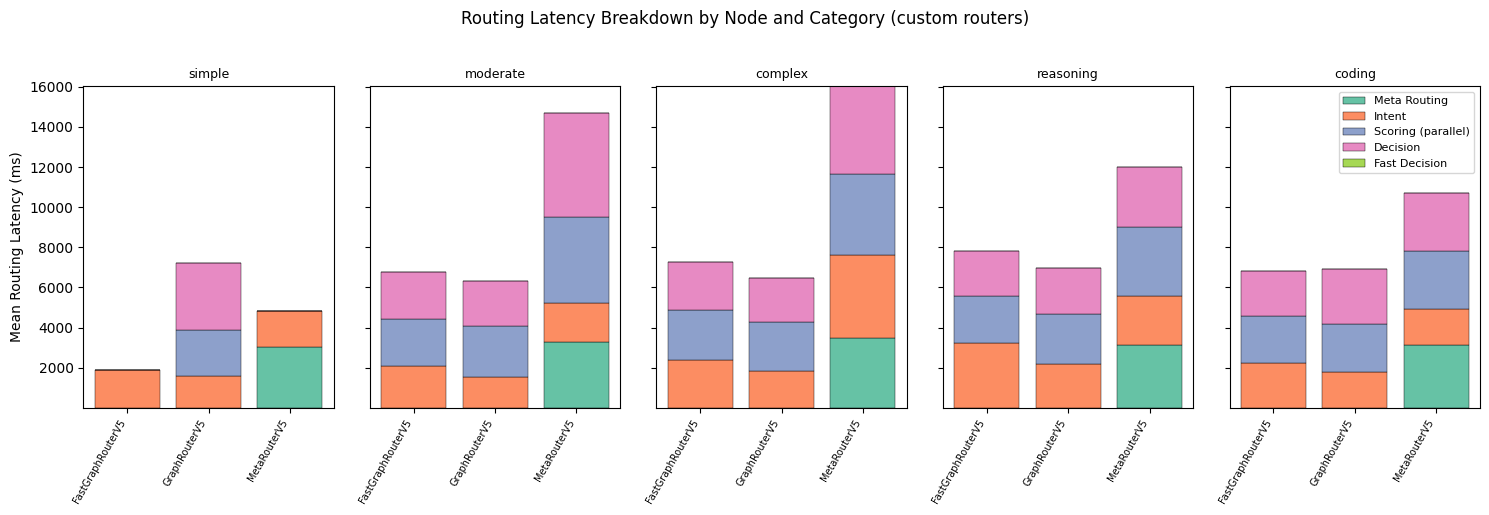

In [21]:
fig, _ = plot_node_breakdown_per_category(step_df, router_order=router_order)
fig.savefig(
    "./source/group_step_latency.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

These figures provide a breakdown of routing latency by node and clearly illustrate the contribution of each component to the overall routing overhead. Intent classification is usually one of the smaller components, while the scoring and decision nodes contribute more to the routing overhead.

In addition, the meta-routing node introduces considerable latency in MetaRouter, further increasing the overall routing cost. As a result, MetaRouter generally has higher routing overhead than FastGraphRouter and GraphRouter.

### Cost Analysis

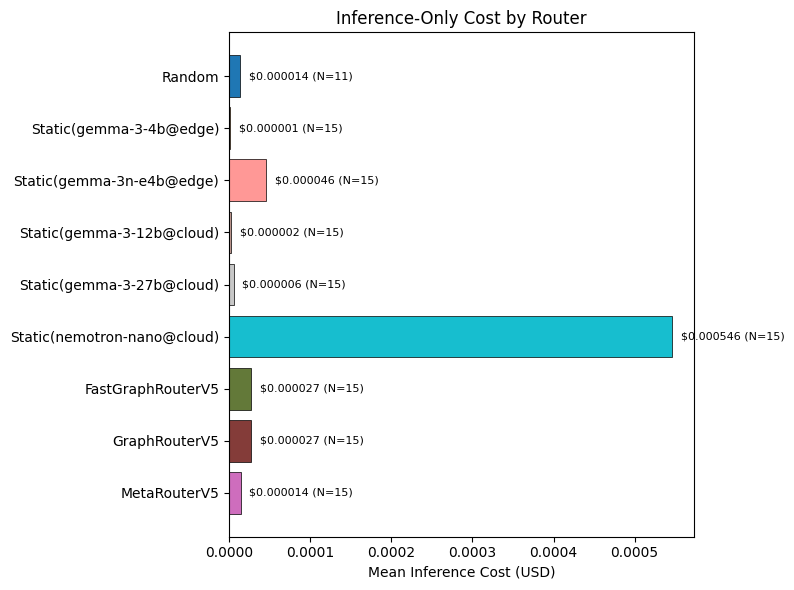

In [22]:
fig, _ = plot_cost_inference_overall(evaluation_df, router_order=router_order, show_errorbar=False)
fig.savefig("./source/inference_cost.png")

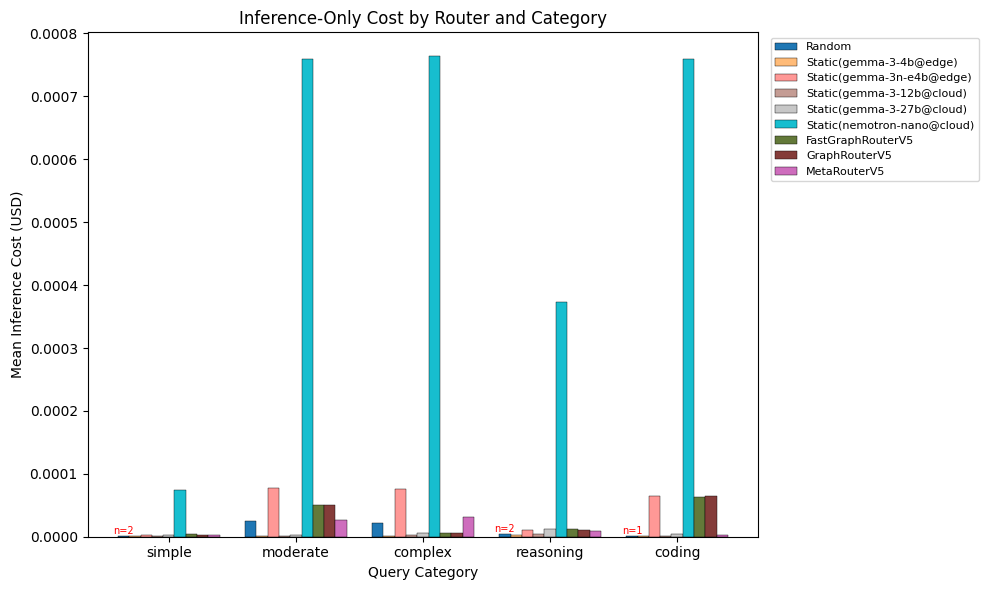

In [23]:
fig, _ = plot_cost_inference_per_category(evaluation_df, router_order=router_order, show_errorbar=False)
fig.savefig(
    "./source/group_inference_cost.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

From this figure, we can notice that `gemma-3n-e4b` is a small LLM deploy on edge, but it has a higher inference cost than some medium-tier cloud-deployed models. At the same time, the earlier quality comparison shows that its quality score is comparable to those medium-tier models. This suggests that `gemma-3n-e4b` may generate more output tokens when answering queries.

The inference cost of the LLM model selected by the custom routers is generally lower that the cost of using `gemma-3n-e4b` and `nemotron-nano`. This indicates that adaptive routing can help reduce inference cost by selecting cheaper models when appropriate.

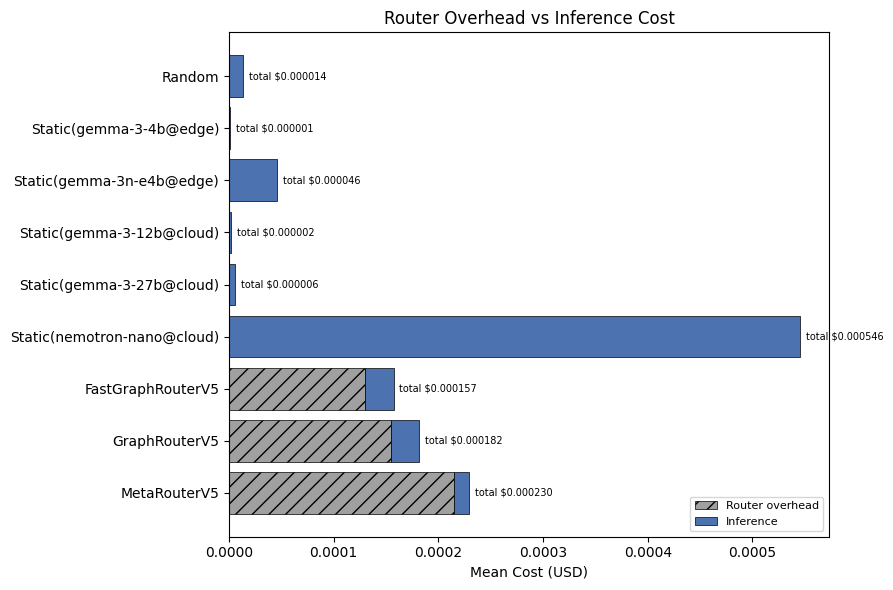

In [24]:
fig, _ = plot_cost_split_overall(evaluation_df, router_order=router_order)
fig.savefig("./source/overall_cost.png")

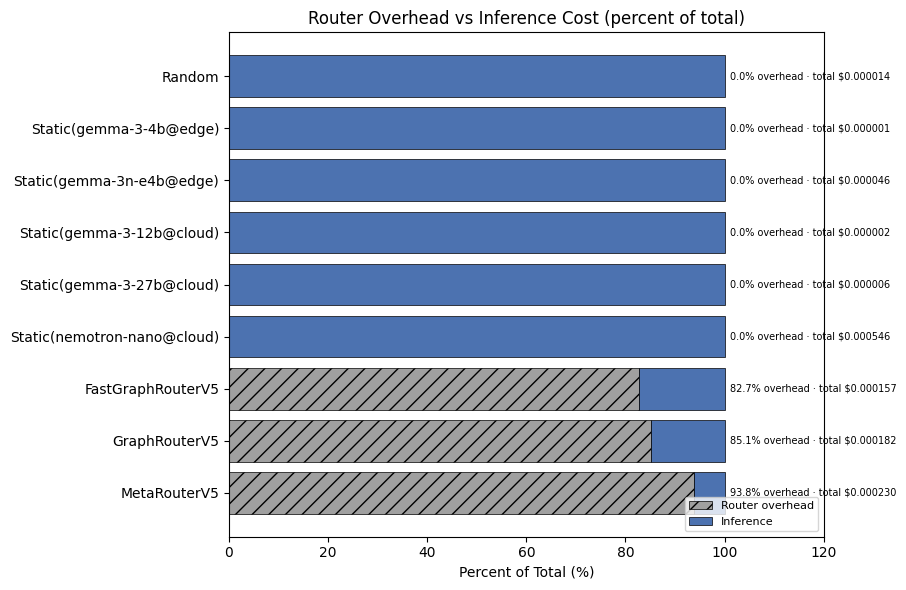

In [25]:
fig, _ = plot_cost_split_overall_pct(evaluation_df, router_order=router_order)
fig.savefig("./source/overall_cost_percentage.png")

These two figure clearly show that the total cost of custom routers becomes higher than most static baselines. The routing pipeline accounts for more than 80\% of the total cost required to answer a query. This indicates that the cost is dominated not by final inference, but by the additional LLM calls used inside the routing pipeline.

One possible reason is that the router uses `gemma-3n-e4b` as the default LLM in the router. Although this is a small edge-deployed model, the earlier inference-cost results show that it can still be more expensive than some medium-tier cloud models. Since the router calls this model multiple times for intent classification, scoring, and decision-making, this makes routing cost becomes substantial.

Comparing across custom routers, FastGraphRouter generally has lower total cost than GraphRouter and MetaRouter. This is because FastGraphRouter can use its fast decision path to skip part of the routing pipeline for simple factual queries. In contrast, MetaRouter tends to be more expensive because it includes an additional meta-routing step.

Overall, adaptive routing can reduce inference cost by selecting cheaper models for final answering, but the routing pipeline itself introduces a large additional cost.

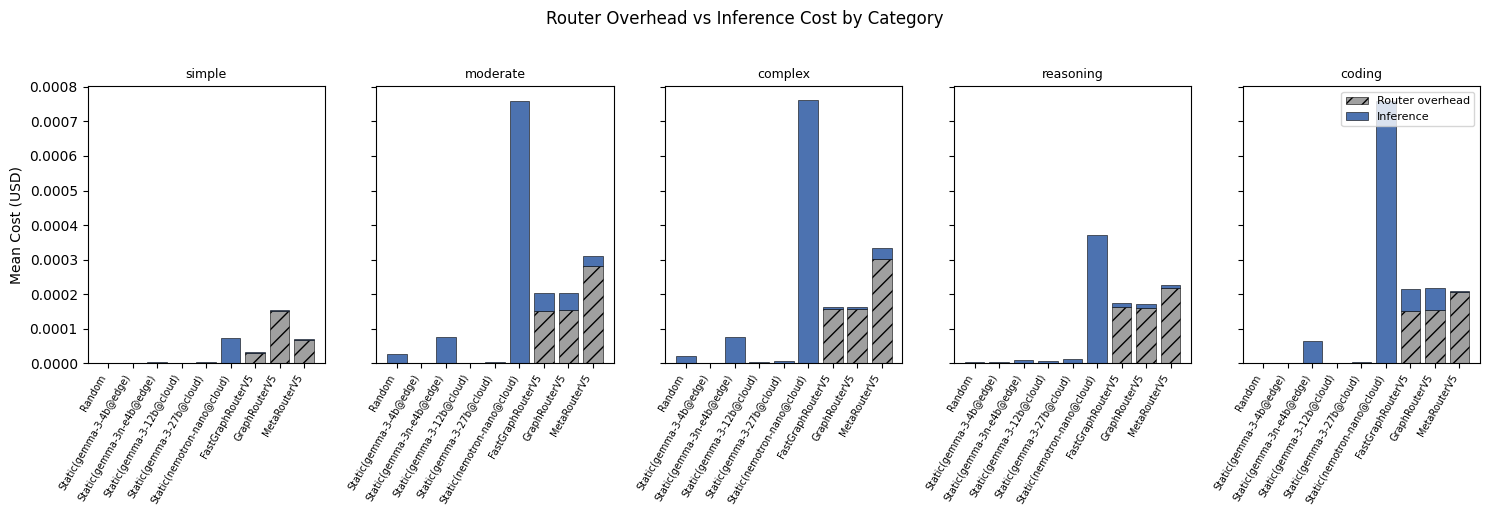

In [26]:
fig, _ = plot_cost_split_per_category(evaluation_df, router_order=router_order)
fig.savefig(
    "./source/group_cost.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

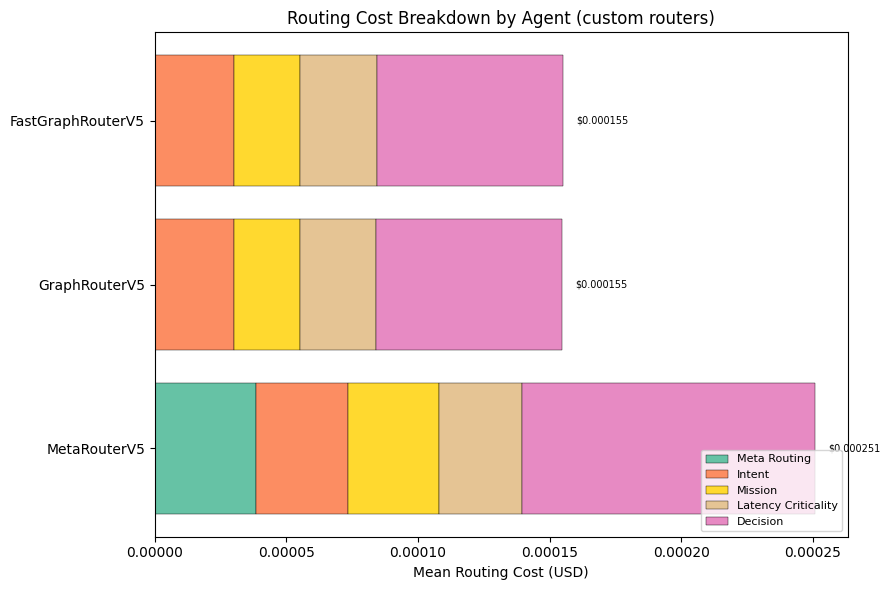

In [27]:
fig, _ = plot_cost_node_breakdown_overall(step_df, router_order=router_order)
fig.savefig("./source/step_cost.png")

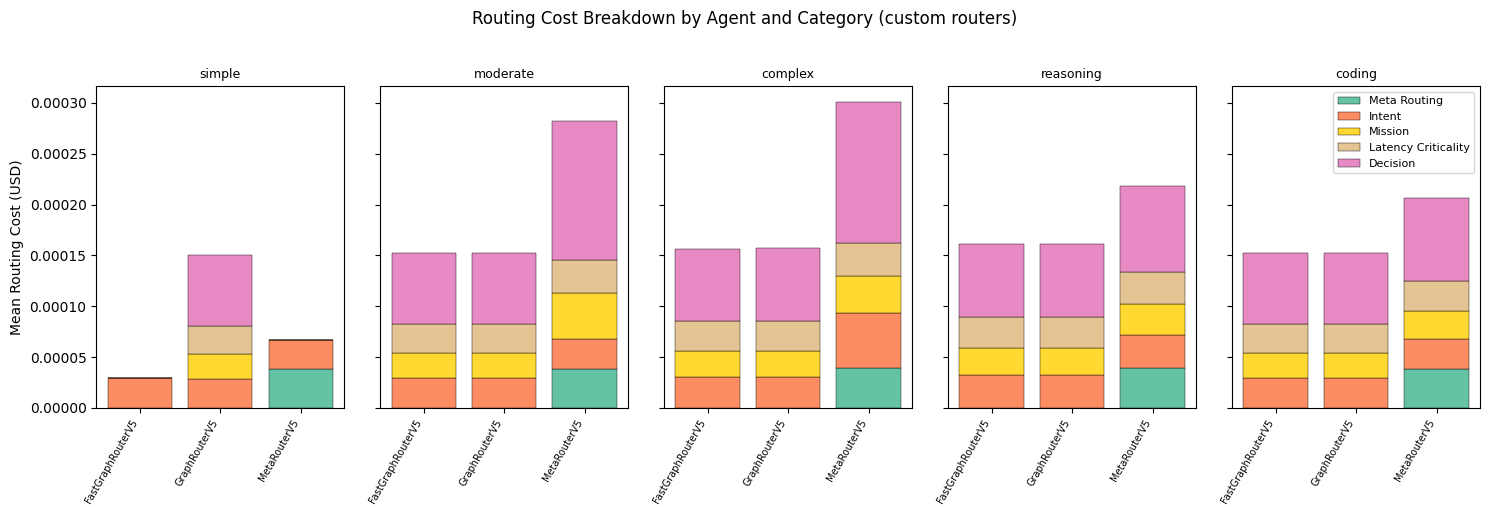

In [28]:
fig, _ = plot_cost_node_breakdown_per_category(step_df, router_order=router_order)
fig.savefig(
    "./source/group_step_cost.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,
)

These two figures show the detailed cost breakdown of each node in the custom routing pipeline. Overall, the decision node contributes the largest share of routing cost compared with the other nodes. This is likely because the decision node needs to combine information from intent classification, mission-criticality scoring, and latency-criticality scoring, and then generate reasoning for the selected LLM and deployment. As a result, it consumes more input and output tokens than the other routing nodes.

Across query categories, the routing cost generally increases as query complexity increases. More complex queries require more reasoning during model selection, which leads to higher token usage and higher routing cost.

For FastGraphRouter, the fast decision path helps reduce routing cost for simple queries. When a query is identified as simple factual, the router can skip the scoring and decision nodes, so the overhead only comes from the intent node. This significantly reduces the cost compared with running the full routing pipeline.